In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


In [12]:
# =========================
# Lecture du fichier CSV
# =========================
csv_file = ".\\inputs\\straightlineleft.csv"

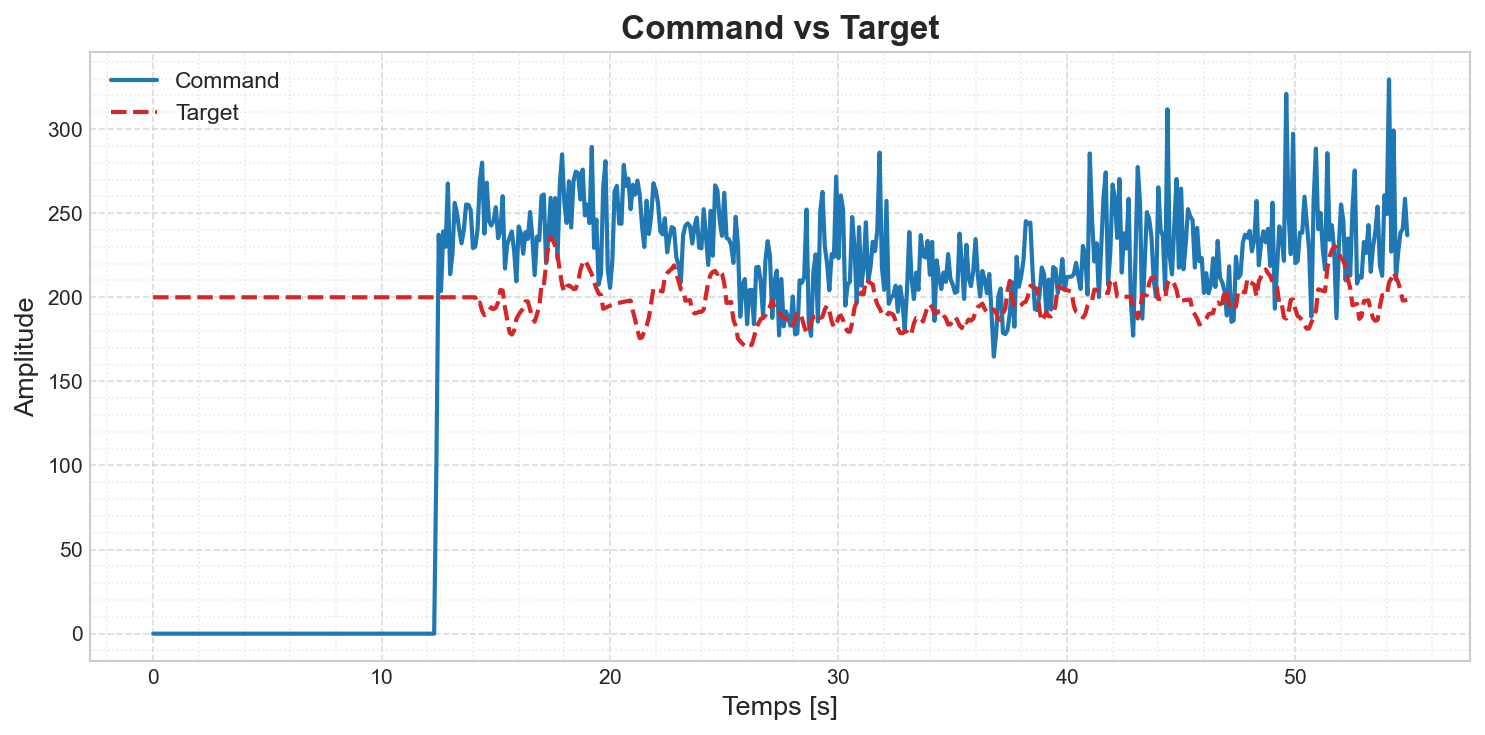

In [13]:
df = pd.read_csv(csv_file)

# =========================
# Garder à partir de la 300ème valeur
# =========================
df = df.iloc[3200:3750].reset_index(drop=True)

# =========================
# Rééchantillonnage à 1/20 s
# =========================
# Pas temporel = 0.05 s
dt = 1 / 20

# Temps relatif
t = df["Command_x"] - df["Command_x"].iloc[0]

# Création d'une grille temporelle régulière
t_uniform = pd.Series(
    np.arange(t.min(), t.max(), dt)
)

# Interpolation des signaux
command_interp = np.interp(
    t_uniform,
    t,
    df["Command_y"]
)

target_interp = np.interp(
    t_uniform,
    t,
    df["Target_y"]
)

# =========================
# Style scientifique
# =========================
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

# =========================
# Tracé
# =========================
ax.plot(
    t_uniform,
    command_interp,
    label="Command",
    linewidth=2,
    color="tab:blue"
)

ax.plot(
    t_uniform,
    target_interp,
    label="Target",
    linewidth=2,
    linestyle="--",
    color="tab:red"
)

# =========================
# Mise en forme
# =========================
ax.set_title("Command vs Target", fontsize=16, fontweight="bold")
ax.set_xlabel("Temps [s]", fontsize=13)
ax.set_ylabel("Amplitude", fontsize=13)

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3, 3))

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.grid(True, which='major', linestyle='--', alpha=0.7)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', alpha=0.4)

ax.legend(fontsize=11)

fig.tight_layout()

plt.show()